# Fuzzy Membership Functions

Visualization of trapezoidal membership functions used in `agent/rl/fuzzy.py`.  
All metrics are normalized to a 0–100% scale with 3 levels: **Low**, **Medium**, **High**.

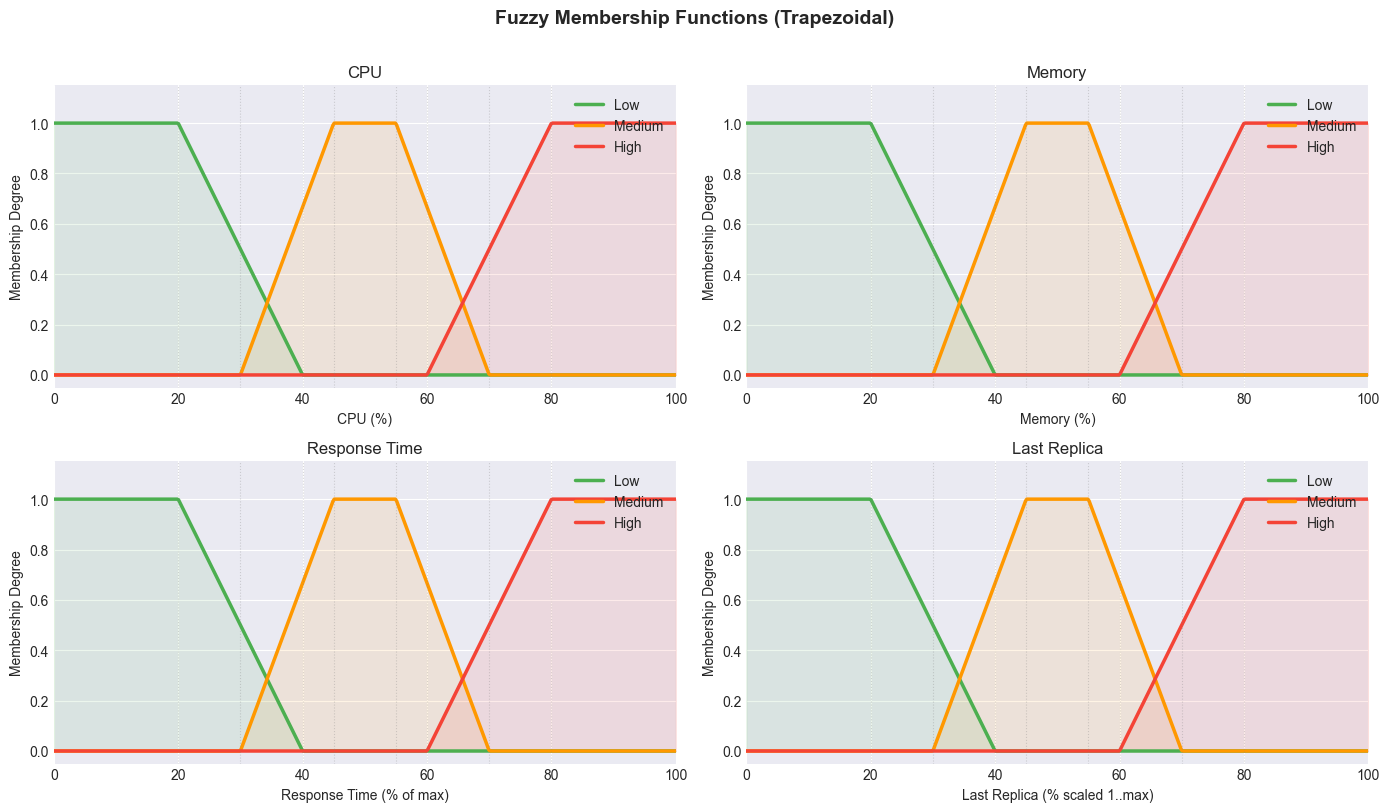

Overlap zones:
  Low-Medium : 30–40%  (both active)
  Medium-High: 60–70%  (both active)
  Pure Low   :  0–20%  (membership = 1.0)
  Pure Medium: 45–55%  (membership = 1.0)
  Pure High  : 80–100% (membership = 1.0)


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

def trapezoidal(x, a, b, c, d):
    y = np.zeros_like(x, dtype=float)
    for i, v in enumerate(x):
        if v < a or v > d:
            y[i] = 0.0
        elif b <= v <= c:
            y[i] = 1.0
        elif a < v < b:
            y[i] = (v - a) / (b - a) if (b - a) != 0 else 0.0
        else:
            y[i] = (d - v) / (d - c) if (d - c) != 0 else 0.0
    return y

# Membership definitions (from fuzzy.py)
memberships = {
    "low":    (0, 0, 20, 40),
    "medium": (30, 45, 55, 70),
    "high":   (60, 80, 100, 100),
}
colors = {"low": "#4CAF50", "medium": "#FF9800", "high": "#F44336"}

metrics = [
    ("CPU", "%"),
    ("Memory", "%"),
    ("Response Time", "% of max"),
    ("Last Replica", "% scaled 1..max"),
]

x = np.linspace(0, 100, 500)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (title, unit) in zip(axes.flat, metrics):
    for label, params in memberships.items():
        y = trapezoidal(x, *params)
        ax.plot(x, y, linewidth=2.5, label=label.capitalize(), color=colors[label])
        ax.fill_between(x, y, alpha=0.1, color=colors[label])

    ax.set_xlabel(f'{title} ({unit})')
    ax.set_ylabel('Membership Degree')
    ax.set_title(f'{title}')
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.05, 1.15)
    ax.legend(loc='upper right')

    # Mark key boundaries
    for v in [20, 40, 30, 45, 55, 60, 70, 80]:
        ax.axvline(x=v, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)

fig.suptitle('Fuzzy Membership Functions (Trapezoidal)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print overlap zones
print('Overlap zones:')
print('  Low-Medium : 30–40%  (both active)')
print('  Medium-High: 60–70%  (both active)')
print('  Pure Low   :  0–20%  (membership = 1.0)')
print('  Pure Medium: 45–55%  (membership = 1.0)')
print('  Pure High  : 80–100% (membership = 1.0)')